In [1]:
load("ProcessData.RData")
library(dplyr)
library(stringr)
library(ggplot2)
library(tidyr)
library(jsonlite)
library(purrr)
library(svglite)
library(ggpmisc)
library(ggplot2)
library(tidyverse)
combined_df <- subset(combined_df, unique_SNVs > 500)
Hiatt <- subset(Hiatt, unique_SNVs > 500)
LeeSix <- subset(LeeSix, unique_SNVs > 500)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘purrr’


The following object is masked from ‘package:jsonlite’:

    flatten


Loading required package: ggpp

Registered S3 methods overwritten by 'ggpp':
  method                  from   
  heightDetails.titleGrob ggplot2
  widthDetails.titleGrob  ggplot2


Attaching package: ‘ggpp’


The following object is masked from ‘package:ggplot2’:

    annotate


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.1     ✔ readr     2.1.6
✔ lubridate 1.9.4     ✔ tibble    3.3.1
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ ggpp::annotate() masks ggplot2::annotate()
✖ dplyr::filter()  masks stats::filter()
✖ purrr::flatten() masks jsonlite::flatten()
✖ dplyr::lag()     masks stats::lag()
ℹ Use t

In [2]:
all_cols <- names(Hiatt)
sig_prefixes <- c("^SBS", "^ID")  # prefixes for signature columns
sig_cols <- all_cols[Reduce(`|`, lapply(sig_prefixes, function(p) grepl(p, all_cols)))]
sig_cols <- sig_cols[!grepl("_", sig_cols)]

region_order <- c("Right", "cecum", "asc_col", "trans_col",
                  "desc_col", "sig_col", "rectum", "Left")

In [3]:
# -----------------------------
# MANUAL SIGNATURE ORDER
# -----------------------------

SBS_order <- c(
  "SBS1","SBS5","SBS40a","SBS18","SBS23",
  "SBS30","SBS36","SBS88","SBS89"
)

ID_order <- c(
  "ID1","ID2","ID3","ID4","ID7","ID9","ID18","ID23"
)

In [4]:
SBS_colors <- c(
  SBS1   = "#2C6DA4",  # muted blue
  SBS5   = "#1F8A70",  # deep teal (dominant but calmer)
  SBS40a = "#66C2A4",  # lighter seafoam (clear separation from SBS5)

  SBS18  = "#D95F02",  # controlled orange (keep as anchor warm tone)
  SBS23  = "#6C5B9A",  # softened purple
  SBS30  = "#8C510A",  # muted brown
  SBS36  = "#4D9221",  # cooler green (shifted away from teal)

  SBS88  = "#A11D6F",  # harmonized magenta (same family as ID18)
  SBS89  = "#C7A100"   # muted mustard
)

ID_colors <- c(
  ID1  = "#A05000",  # muted burnt sienna
  ID2  = "#D8903C",  # soft amber (paired)

  ID3  = "#6C5B9A",  # softened purple
  ID4  = "#F4A582",  # pale coral

  ID7  = "#2C7FB8",  # blue-teal (colorblind safer)
  ID9  = "#3A7FB0",  # medium blue

  ID18 = "#A11D6F",  # cooled magenta
  ID23 = "#6E6E6E"   # neutral gray anchor
)


In [ ]:
preview_df <- data.frame(
  signature = c(SBS_order, ID_order),
  group = c(rep("SBS", length(SBS_order)),
            rep("ID", length(ID_order)))
)

preview_df$signature <- factor(preview_df$signature,
                               levels = c(SBS_order, ID_order))

ggplot(preview_df,
       aes(x = signature, y = 1, fill = signature)) +
  geom_col() +
  scale_fill_manual(values = c(SBS_colors, ID_colors)) +
  facet_grid(~ group, scales = "free_x", space = "free_x") +
  theme_bw() +
  theme(
    axis.text.y = element_blank(),
    axis.ticks = element_blank(),
    axis.title = element_blank()
  ) +
  ggtitle("Signature Color Preview")

### Panel A: stacked signatures

### Panel 3A: SBS Signatures Overall
Signatures:
- SBS1 (Tumor comparison also)***
- SBS5 (Tumor comparison also)***
- SBS18 (Tumor comparison also)***
- SBS22a - aristocholic acid
- SBS23 - similar to SBS11 and SBS30, maybe higher in distal
- SBS25 (chemotherapy)
- SBS30 - SBS30 is due to deficiency in base excision repair due to inactivating mutations in NTHL1.
- SBS36 - MUTYH → defective DNA BER
- SBS40a - flat, like SBS5
- SBS45 - ARTIFACT
- SBS88 - colibactin
- SBS89 - flat, happens early in life 
- SBS95 - ARTIFACT


In [ ]:
library(dplyr)
library(tidyr)
library(ggplot2)
library(ggnewscale)

# -----------------------------
# Prepare SBS data
# -----------------------------

df_sbs <- Hiatt %>%
  select(crypt_sample, region, cohort, all_of(SBS_order)) %>%
  pivot_longer(
    cols = all_of(SBS_order),
    names_to = "signature",
    values_to = "value"
  ) %>%
  group_by(crypt_sample) %>%
  mutate(
    total = sum(value, na.rm = TRUE),
    prop  = ifelse(total == 0, 0, value / total)
  ) %>%
  ungroup() %>%
  mutate(
    region = factor(region, levels = region_order),
    signature = factor(signature, levels = SBS_order)
  ) %>%
  arrange(cohort, region) %>%
  mutate(xid = paste(cohort, region, crypt_sample, sep = "_"))

df_sbs$xid <- factor(df_sbs$xid, levels = unique(df_sbs$xid))

# -----------------------------
# Region strip
# -----------------------------

region_strip_sbs <- df_sbs %>%
  select(xid, region, cohort) %>%
  distinct() %>%
  mutate(ymin = 1.02, ymax = 1.05)

region_colors <- colorRampPalette(c("blue","white","red"))(length(region_order))
names(region_colors) <- region_order

# -----------------------------
# Plot SBS
# -----------------------------

p_sbs <- ggplot() +
  geom_col(
    data = df_sbs,
    aes(x = xid, y = prop, fill = signature),
    width = 1
  ) +
  scale_fill_manual(values = SBS_colors,
                    name = "SBS Signature",
                    guide = guide_legend(ncol = 2)) +
  ggnewscale::new_scale_fill() +
  geom_tile(
    data = region_strip_sbs,
    aes(x = xid, y = (ymin + ymax)/2, fill = region),
    height = 0.03
  ) +
  scale_fill_manual(values = region_colors,
                    name = "Region") +
  facet_grid(~ cohort, scales = "free_x", space = "free_x") +
  theme_bw() +
  theme(
    axis.text.x  = element_blank(),
    axis.ticks.x = element_blank(),
    strip.text   = element_text(size = 12, face = "bold")
  ) +
  ylab("Proportion of SBS contribution") +
  xlab("Samples (grouped by region inside cohort)") +
  ggtitle("SBS Signatures")

p_sbs

ggsave("Figure3/cohortsigs_SBS.svg", p_sbs, width = 10, height = 8)

### Panel 4A: ID Signatures Overall
Signatures:
- ID1 (Tumor comparison also)***
- ID2 (Tumor comparison also)***
- ID18 (Tumor comparison also)***
- ID3 Associated with tobacco smoking. associated with DBS2
- ID4 large numbers of mutations in a subset of samples which do not obviously have the mutational features of defective DNA mismatch repair.
- ID7 Defective DNA mismatch repair
- ID9 Unknown 
- ID23 Aristocholic acid 

In [ ]:
# -----------------------------
# Prepare ID data
# -----------------------------

df_id <- Hiatt %>%
  select(crypt_sample, region, cohort, all_of(ID_order)) %>%
  pivot_longer(
    cols = all_of(ID_order),
    names_to = "signature",
    values_to = "value"
  ) %>%
  group_by(crypt_sample) %>%
  mutate(
    total = sum(value, na.rm = TRUE),
    prop  = ifelse(total == 0, 0, value / total)
  ) %>%
  ungroup() %>%
  mutate(
    region = factor(region, levels = region_order),
    signature = factor(signature, levels = ID_order)
  ) %>%
  arrange(cohort, region) %>%
  mutate(xid = paste(cohort, region, crypt_sample, sep = "_"))

df_id$xid <- factor(df_id$xid, levels = unique(df_id$xid))

# -----------------------------
# Region strip
# -----------------------------

region_strip_id <- df_id %>%
  select(xid, region, cohort) %>%
  distinct() %>%
  mutate(ymin = 1.02, ymax = 1.05)

# -----------------------------
# Plot ID
# -----------------------------

p_id <- ggplot() +
  geom_col(
    data = df_id,
    aes(x = xid, y = prop, fill = signature),
    width = 1
  ) +
  scale_fill_manual(values = ID_colors,
                    name = "ID Signature",
                    guide = guide_legend(ncol = 2)) +
  ggnewscale::new_scale_fill() +
  geom_tile(
    data = region_strip_id,
    aes(x = xid, y = (ymin + ymax)/2, fill = region),
    height = 0.03
  ) +
  scale_fill_manual(values = region_colors,
                    name = "Region") +
  facet_grid(~ cohort, scales = "free_x", space = "free_x") +
  theme_bw() +
  theme(
    axis.text.x  = element_blank(),
    axis.ticks.x = element_blank(),
    strip.text   = element_text(size = 12, face = "bold")
  ) +
  ylab("Proportion of ID contribution") +
  xlab("Samples (grouped by region inside cohort)") +
  ggtitle("Indel Signatures")

p_id

ggsave("Figure4/cohortsigs_ID.svg", p_id, width = 10, height = 8)

### Panel B
cornish comparison!

In [ ]:
Cornish_site_SNV <- data.frame(
                       stringsAsFactors = FALSE,
  primary_tumour_site_more_specific_idx = c("cecum","asc_col","HF",
                                            "trans_col","SF","desc_col",
                                            "sig_col","RS","rectum"),
                             n_snv_Mean = c(14467,14563,14701,
                                            14747,12253,13149,12554,10686,11235),
                                 Median = c(13318,13544,12817,
                                            12867,10507,11826,10725,9496,10176),
                                Minimum = c(5008,6016,7739,5370,
                                            5449,4006,5018,4703,3402),
                                Maximum = c(43732,48510,46033,
                                            43643,23472,42561,47847,27835,42638),
                     Standard.Deviation = c(6378,6636,7974,6842,
                                            5061,7280,6289,4093,5427),
                    Interquartile.Range = c(6428,6362,5398,8255,
                                            6188,6751,5944,4270,5162),
                              n.tumours = c(158L,79L,21L,60L,21L,
                                            34L,262L,98L,173L)
)


Cornish_site_SNVs <- tibble::tribble(
  ~region_key, ~Cornish_Mean, ~Cornish_Median, ~Cornish_Minimum, ~Cornish_Maximum,
  "cecum",   14467, 13318, 5008,  43732,
  "asc_col", 14563, 13544, 6016,  48510,
  "HF",      14701, 12817, 7739,  46033,
  "trans_col",14747,12867, 5370,  43643,
  "SF",      12253, 10507, 5449,  23472,
  "desc_col",13149,11826, 4006,  42561,
  "sig_col", 12554,10725, 5018,  47847,
  "RS",      10686, 9496,  4703,  27835,
  "rectum",  11235,10176, 3402,  42638
)

# ---- DEFINE Cornish reference data.frames (numeric values — no commas) ----
Cornish_SNVs <- data.frame(
  region_key = c("cecum","asc_col","HF","trans_col","SF","desc_col","sig_col","RS","rectum"),
  Cornish_Mean = c(14467, 14563, 14701, 14747, 12253, 13149, 12554, 10686, 11235),
  Cornish_SD   = c(6378, 6636, 7974, 6842, 5061, 7280, 6289, 4093, 5427),
  stringsAsFactors = FALSE
)

Cornish_INDELs <- data.frame(
  region_key = c("cecum","asc_col","HF","trans_col","SF","desc_col","sig_col","RS","rectum"),
  Cornish_Mean = c(1988,1804,1615,1679,1502,1734,1452,1333,1292),
  Cornish_SD   = c(1263,712,507,714,819,920,689,593,510),
  stringsAsFactors = FALSE
)

Cornish_SBS18 <- data.frame(
  region_key = c("cecum","asc_col","HF","trans_col","SF","desc_col","sig_col","RS","rectum"),
  Cornish_Mean = c(3807.98,3375.80,3482.71,3056.58,2309.67,2628.68,2226.31,2244.63,1916.16),
  Cornish_SD   = c(2523.83,1565.50,1402.03,2211.55,1803.30,2046.63,1790.99,1445.30,1394.51),
  stringsAsFactors = FALSE
)

Cornish_SBS1 <- data.frame(
  region_key = c("cecum","asc_col","HF","trans_col","SF","desc_col","sig_col","RS","rectum"),
  Cornish_Mean = c(2320.16,2331.44,2239.48,2268.68,1955.38,1976.35,1853.96,1823.53,1785.93),
  Cornish_SD   = c(915.63,911.38,618.52,715.21,583.03,917.33,672.62,705.91,655.73),
  stringsAsFactors = FALSE
)

Cornish_SBS5 <- data.frame(
  region_key = c("cecum","asc_col","HF","trans_col","SF","desc_col","sig_col","RS","rectum"),
  Cornish_Mean = c(5401.74,5432.66,5623.10,5330.62,5381.14,5006.29,4458.89,4423.61,4385.60),
  Cornish_SD   = c(2525.62,2432.57,4465.54,2432.91,2599.82,2248.67,2150.13,1451.04,1666.24),
  stringsAsFactors = FALSE
)

Cornish_ID18 <- data.frame(
  region_key = c("cecum","asc_col","HF","trans_col","SF","desc_col","sig_col","RS","rectum"),
  Cornish_Mean = c(29.25,24.32,40.19,15.78,49.52,33.82,40.39,68.62,92.84),
  Cornish_SD   = c(142.37,111.71,175.27,64.45,125.31,94.09,129.90,124.93,170.07),
  stringsAsFactors = FALSE
)

Cornish_ID1 <- data.frame(
  region_key = c("cecum","asc_col","HF","trans_col","SF","desc_col","sig_col","RS","rectum"),
  Cornish_Mean = c(1003.53,869.67,777.38,799.08,728.33,859.00,661.12,666.17,588.47),
  Cornish_SD   = c(1028.05,365.33,248.58,357.31,422.03,432.08,316.71,313.51,273.67),
  stringsAsFactors = FALSE
)

Cornish_ID2 <- data.frame(
  region_key = c("cecum","asc_col","HF","trans_col","SF","desc_col","sig_col","RS","rectum"),
  Cornish_Mean = c(940.35,838.67,808.86,807.33,715.90,805.65,613.67,556.61,538.84),
  Cornish_SD   = c(482.24,436.48,216.09,392.54,451.04,629.53,436.80,324.21,328.95),
  stringsAsFactors = FALSE
)
region_levels <- c("cecum","asc_col","HF",
                                            "trans_col","SF","desc_col",
                                            "sig_col","RS","rectum")

#Hiatt2 <- subset(Hiatt, cohort == "adenoma")

Hiatt2 <- Hiatt

summary_uniqueSNVs <- Hiatt2 %>%
  group_by(region) %>%
  summarise(
    Mean = mean(unique_SNVs, na.rm = TRUE),
    Median = median(unique_SNVs, na.rm = TRUE),
    Minimum = min(unique_SNVs, na.rm = TRUE),
    Maximum = max(unique_SNVs, na.rm = TRUE),
    SD = sd(unique_SNVs, na.rm = TRUE),
    IQR = IQR(unique_SNVs, na.rm = TRUE),
    n_crypts = n()
  ) %>%
  arrange(factor(region, levels = c(
    "cecum", "asc_col", "HF", "trans_col", "SF",
    "desc_col", "sig_col", "RS", "rectum"
  )))


In [ ]:
region_col <- "region"
cohort_col <- "cohort"

df_raw <- Hiatt

plot_columns <- c(
  "unique_SNVs",
  "total_indels",
  "SBS18",
  "SBS1",
  "SBS5",
  "ID18",
  "ID1",
  "ID2"
)

# ------------------------------
# cohort normalisation
# ------------------------------
normalise_cohort <- function(x) {
  x0 <- ifelse(is.na(x) | x == "", NA_character_, tolower(x) %>% str_trim())
  xc <- str_replace_all(x0, "[^a-z0-9]", "")
  dplyr::case_when(
    xc %in% c("normal","n","norm","ctrl","control","healthy","nonneoplastic") ~ "normal",
    xc %in% c("adenoma","adeno","adenomatous") ~ "adenoma",
    xc %in% c("carcinoma","crc","cancer","tumour","tumor") ~ "carcinoma",
    TRUE ~ ifelse(is.na(x0), "unknown", x0)
  )
}

# ------------------------------
# Cornish bowel order
# ------------------------------
cornish_order <- c(
  "cecum",
  "asc_col",
  "HF",
  "trans_col",
  "SF",
  "desc_col",
  "sig_col",
  "RS",
  "rectum"
)

# ------------------------------
# base dataframe
# ------------------------------
df_base <- df_raw %>%
  mutate(
    region = as.character(.data[[region_col]]) %>% str_trim(),
    cohort_raw = if (cohort_col %in% names(df_raw)) as.character(.data[[cohort_col]]) else NA_character_,
    cohort = normalise_cohort(cohort_raw)
  ) %>%
  mutate(
    region = if_else(
      region %in% c("C","AC","HC","TC","DC","S","R"),
      recode(
        region,
        "C"  = "cecum",
        "AC" = "asc_col",
        "HC" = "HF",
        "TC" = "trans_col",
        "DC" = "desc_col",
        "S"  = "sig_col",
        "R"  = "rectum"
      ),
      region
    )
  )

present_regions <- intersect(unique(df_base$region), cornish_order)
if (length(present_regions) == 0)
  stop("No overlapping regions between your data and expected region keys.")

region_levels <- cornish_order[cornish_order %in% present_regions]

df_base <- df_base %>%
  filter(region %in% region_levels) %>%
  mutate(
    region = factor(region, levels = region_levels),
    cohort = factor(cohort, levels = c("normal","adenoma","carcinoma"))
  )

In [ ]:
df_long <- df_base %>%
  pivot_longer(
    cols = all_of(plot_columns),
    names_to = "signature",
    values_to = "value"
  )

plot_faceted_signature_page <- function(signature_name, cornish_df) {

  df_sig <- df_long %>%
    filter(signature == signature_name)

  summary_sig <- df_sig %>%
    group_by(region, cohort) %>%
    summarise(
      mean = mean(value, na.rm = TRUE),
      sd   = sd(value, na.rm = TRUE),
      .groups = "drop"
    )

  # ----------------------------------
  # Cornish scaling
  # ----------------------------------
  max_you     <- max(summary_sig$mean, na.rm = TRUE)
  max_cornish <- max(cornish_df$Cornish_Mean, na.rm = TRUE)

  scale_factor <- ifelse(
    is.na(max_you) | max_you <= 0,
    1,
    pmax(1, max_cornish / max_you * 0.9)
  )

  cornish_df <- cornish_df %>%
    mutate(
      Cornish_Mean_scaled = Cornish_Mean / scale_factor,
      Cornish_SD_scaled   = Cornish_SD   / scale_factor,
      region_key = factor(region_key, levels = region_levels)
    )

  # ----------------------------------
  # Arrow height: above *all* error bars
  # ----------------------------------
  max_cohort <- max(summary_sig$mean + summary_sig$sd, na.rm = TRUE)
  max_corn   <- max(
    cornish_df$Cornish_Mean_scaled + cornish_df$Cornish_SD_scaled,
    na.rm = TRUE
  )

  y_arrow_base <- max(max_cohort, max_corn)

  # ----------------------------------
  # Direction arrows: cohorts
  # ----------------------------------
  arrow_df <- summary_sig %>%
    mutate(region_num = as.numeric(region)) %>%
    group_by(cohort) %>%
    summarise(
      slope = coef(lm(mean ~ region_num))[2],
      .groups = "drop"
    ) %>%
    mutate(
      direction = ifelse(slope > 0, "up", "down"),
      x_from = ifelse(direction == "up",
                      region_levels[1],
                      region_levels[length(region_levels)]),
      x_to   = ifelse(direction == "up",
                      region_levels[length(region_levels)],
                      region_levels[1]),
      y = y_arrow_base * case_when(
        cohort == "normal"  ~ 1.08,
        cohort == "adenoma" ~ 1.14,
        TRUE                ~ 1.08
      )
    )

  # ----------------------------------
  # Cornish direction arrow
  # ----------------------------------
  cornish_arrow <- cornish_df %>%
    mutate(region_num = as.numeric(region_key)) %>%
    summarise(
      slope = coef(lm(Cornish_Mean ~ region_num))[2]
    ) %>%
    mutate(
      direction = ifelse(slope > 0, "up", "down"),
      x_from = ifelse(direction == "up",
                      region_levels[1],
                      region_levels[length(region_levels)]),
      x_to   = ifelse(direction == "up",
                      region_levels[length(region_levels)],
                      region_levels[1]),
      y = y_arrow_base * 1.22
    )

  # ----------------------------------
  # Plot
  # ----------------------------------
  p <- ggplot(summary_sig, aes(x = region, y = mean, color = cohort)) +

    ## ---- Cornish error bars (back) ----
    geom_errorbar(
      data = cornish_df,
      aes(
        x = region_key,
        ymin = Cornish_Mean_scaled - Cornish_SD_scaled,
        ymax = Cornish_Mean_scaled + Cornish_SD_scaled
      ),
      inherit.aes = FALSE,
      width = 0.15,
      linewidth = 0.6,
      alpha = 0.6,
      color = "grey50"
    ) +

    ## ---- Cohort error bars (back) ----
    geom_errorbar(
      aes(
        ymin = mean - sd,
        ymax = mean + sd,
        group = cohort
      ),
      width = 0.18,
      linewidth = 0.6,
      alpha = 0.6
    ) +

    ## ---- Cornish mean line + points ----
    geom_line(
      data = cornish_df,
      aes(x = region_key, y = Cornish_Mean_scaled, group = 1),
      inherit.aes = FALSE,
      color = "black",
      linewidth = 1
    ) +
    geom_point(
      data = cornish_df,
      aes(x = region_key, y = Cornish_Mean_scaled),
      inherit.aes = FALSE,
      color = "black",
      size = 2
    ) +

    ## ---- Cohort trend lines + points ----
    geom_line(aes(group = cohort), linewidth = 1) +
    geom_point(size = 2.2) +

    ## ---- Cohort arrows ----
    geom_segment(
      data = arrow_df,
      aes(x = x_from, xend = x_to, y = y, yend = y, color = cohort),
      arrow = arrow(length = unit(0.25, "cm"), type = "closed"),
      linewidth = 1,
      inherit.aes = FALSE
    ) +
    geom_text(
      data = arrow_df,
      aes(
        x = x_to,
        y = y,
        label = ifelse(direction == "up", "↑", "↓"),
        color = cohort
      ),
      hjust = ifelse(arrow_df$direction == "up", -0.2, 1.2),
      size = 6,
      fontface = "bold",
      inherit.aes = FALSE
    ) +

    ## ---- Cornish arrow (top) ----
    geom_segment(
      data = cornish_arrow,
      aes(x = x_from, xend = x_to, y = y, yend = y),
      arrow = arrow(length = unit(0.3, "cm"), type = "closed"),
      linewidth = 1.2,
      color = "black",
      inherit.aes = FALSE
    ) +
    geom_text(
      data = cornish_arrow,
      aes(
        x = x_to,
        y = y,
        label = ifelse(direction == "up", "↑", "↓")
      ),
      hjust = ifelse(cornish_arrow$direction == "up", -0.2, 1.2),
      size = 6.5,
      fontface = "bold",
      color = "black",
      inherit.aes = FALSE
    ) +

    scale_color_manual(
      values = c(
        normal  = "#2E7D32",  # green
        adenoma = "#EF6C00"   # orange
      )
    ) +

    scale_x_discrete(
      limits = region_levels,
      labels = c(
        "cecum"="C","asc_col"="AC","HF"="HC",
        "trans_col"="TC","SF"="SF","desc_col"="DC",
        "sig_col"="S","RS"="RS","rectum"="R"
      )
    ) +

    scale_y_continuous(
      name = paste0(signature_name, " (mean ± SD)"),
      sec.axis = sec_axis(
        ~ . * scale_factor,
        name = paste0("Cornish ", signature_name, " (mean ± SD)")
      )
    ) +

    coord_cartesian(clip = "off") +
    theme_bw(base_size = 13) +
    theme(
      axis.text.x = element_text(angle = 45, hjust = 1),
      legend.position = "bottom",
      plot.margin = margin(t = 20, r = 5, b = 5, l = 5)
    )

  print(p)
}


In [ ]:
cornish_snvs <- plot_faceted_signature_page("unique_SNVs",  Cornish_SNVs)
cornish_INDELs <- plot_faceted_signature_page("total_indels", Cornish_INDELs)
cornish_SBS1 <- plot_faceted_signature_page("SBS1",  Cornish_SBS1)
Cornish_SBS5 <- plot_faceted_signature_page("SBS5",  Cornish_SBS5)
cornish_SBS18 <- plot_faceted_signature_page("SBS18", Cornish_SBS18)
cornish_ID1 <- plot_faceted_signature_page("ID1",  Cornish_ID1)
cornish_ID2 <- plot_faceted_signature_page("ID2",  Cornish_ID2)
cornish_ID18 <- plot_faceted_signature_page("ID18", Cornish_ID18)

ggsave(filename = "Figure3/cornish_SNVs.svg", plot = cornish_snvs, width = 10, height = 8, units = "in")
ggsave(filename = "Figure4/cornish_INDELs.svg", plot = cornish_INDELs, width = 10, height = 8, units = "in")
ggsave(filename = "Figure3/cornish_SBS1.svg", plot = cornish_SBS1, width = 10, height = 8, units = "in")
ggsave(filename = "Figure3/cornish_SBS5.svg", plot = Cornish_SBS5, width = 10, height = 8, units = "in")
ggsave(filename = "Figure3/cornish_SBS18.svg", plot = cornish_SBS18, width = 10, height = 8, units = "in")
ggsave(filename = "Figure4/cornish_ID1.svg", plot = cornish_ID1, width = 10, height = 8, units = "in")
ggsave(filename = "Figure4/cornish_ID2.svg", plot = cornish_ID2, width = 10, height = 8, units = "in")
ggsave(filename = "Figure4/cornish_ID18.svg", plot = cornish_ID18, width = 10, height = 8, units = "in")


### Subclonal 

In [5]:
# study dataframes
Hiatt = read.csv('/uufs/chpc.utah.edu/common/HIPAA/u1264408/u1264408/Git/SEMIColon/data/output/CellCut/Hiattdataframe.csv',
                 stringsAsFactors = FALSE, header = TRUE)

Hiatt$sex <- "male"

Hiatt <- Hiatt %>%
  mutate(side = case_when(
    str_detect(region, regex(pattern_right, ignore_case = TRUE)) ~ "Right",
    str_detect(region, regex(pattern_left,  ignore_case = TRUE)) ~ "Left",
    TRUE ~ region
  ))

Hiatt$study <- "Hiatt"

# additional data
denom = read.csv('/uufs/chpc.utah.edu/common/HIPAA/u1264408/u1264408/Git/SEMIColon/data/output/CellCut/mosdepth/per_base/depth8_totals.csv', stringsAsFactors = FALSE, header = FALSE)
colnames(denom)[1] <- "crypt_sample"
colnames(denom)[2] <- "depth"
Hiatt <- merge(denom, Hiatt, by = "crypt_sample")
Hiatt$depth <- as.numeric(Hiatt$depth)

region_order <- c("Right", "cecum", "asc_col", "trans_col", "desc_col", "sig_col", "rectum", "Left")

cohort_order <- c("normal", "adenoma", "carcinoma")
side_order <- c("Right", "Left")


Hiatt$cohort <- factor(Hiatt$cohort)
Hiatt$donor <- factor(Hiatt$donor)
Hiatt$side <- factor(Hiatt$side)
Hiatt$sex <- factor(Hiatt$sex)

Hiatt <- subset(Hiatt, coverage > 9)
Hiatt <- subset(Hiatt, unique_SNVs > 500)

SBSActivities <-  read.csv('/uufs/chpc.utah.edu/common/HIPAA/u1264408/u1264408/Git/SEMIColon/scripts/mutations/signatures/snvs/snvs_subclonal/SBS288/Suggested_Solution/COSMIC_SBS288_Decomposed_Solution/Activities/COSMIC_SBS288_Activities.txt', stringsAsFactors = FALSE, header = TRUE, sep = "\t")
IDActivities <-  read.csv('/uufs/chpc.utah.edu/common/HIPAA/u1264408/u1264408/Git/SEMIColon/scripts/mutations/signatures/ID/ID_subclonal/ID83/Suggested_Solution/COSMIC_ID83_Decomposed_Solution/Activities/COSMIC_ID83_Activities.txt', stringsAsFactors = FALSE, header = TRUE, sep = "\t")

merge_function <- function(x, y) {
  merge(x, y, by = "Samples", all = TRUE) # Adjust 'all' argument for desired join type
}

activities_list <- list(SBSActivities, IDActivities)
Activities <- Reduce(merge_function, activities_list)
Activities <- Activities %>%
  rename("crypt_sample" = "Samples")

Activities[is.na(Activities)] <- 0
Hiatt <- merge(Hiatt, Activities, by = "crypt_sample", all = FALSE)

In [13]:
Hiatt_adenoma <- subset(Hiatt, cohort == "adenoma")
Hiatt_normal <- subset(Hiatt, cohort == "normal")

mean(Hiatt_adenoma$age)
mean(Hiatt_normal$age)

[1] 63.54386

[1] 53.23729

In [6]:
# Add a new column that sums all columns starting with "SBS"
Hiatt$SBS_total <- rowSums(Hiatt[, grepl("^SBS", colnames(Hiatt))], na.rm = TRUE)
# Replace the unique_SNVs column with that total
Hiatt$unique_SNVs <- Hiatt$SBS_total
# (Optional) remove the temporary total column if you don't want to keep it
Hiatt$SBS_total <- NULL
# (Optional) remove the temporary total column if you don't want to keep it
Hiatt$total_indels <- rowSums(Hiatt[, grepl("^ID", colnames(Hiatt))], na.rm = TRUE)

Hiatt <- subset(Hiatt, coverage > 9)

all_cols <- names(Hiatt)
sig_prefixes <- c("^SBS", "^ID")  # prefixes for signature columns
sig_cols <- all_cols[Reduce(`|`, lapply(sig_prefixes, function(p) grepl(p, all_cols)))]
sig_cols <- sig_cols[!grepl("_", sig_cols)]

region_order <- c("Right", "cecum", "asc_col", "trans_col",
                  "desc_col", "sig_col", "rectum", "Left")

Warning message:
“Removed 3 rows containing missing values or values outside the scale range
(`geom_line()`).”
Warning message:
“Removed 3 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 3 rows containing missing values or values outside the scale range
(`geom_line()`).”
Warning message:
“Removed 3 rows containing missing values or values outside the scale range
(`geom_point()`).”


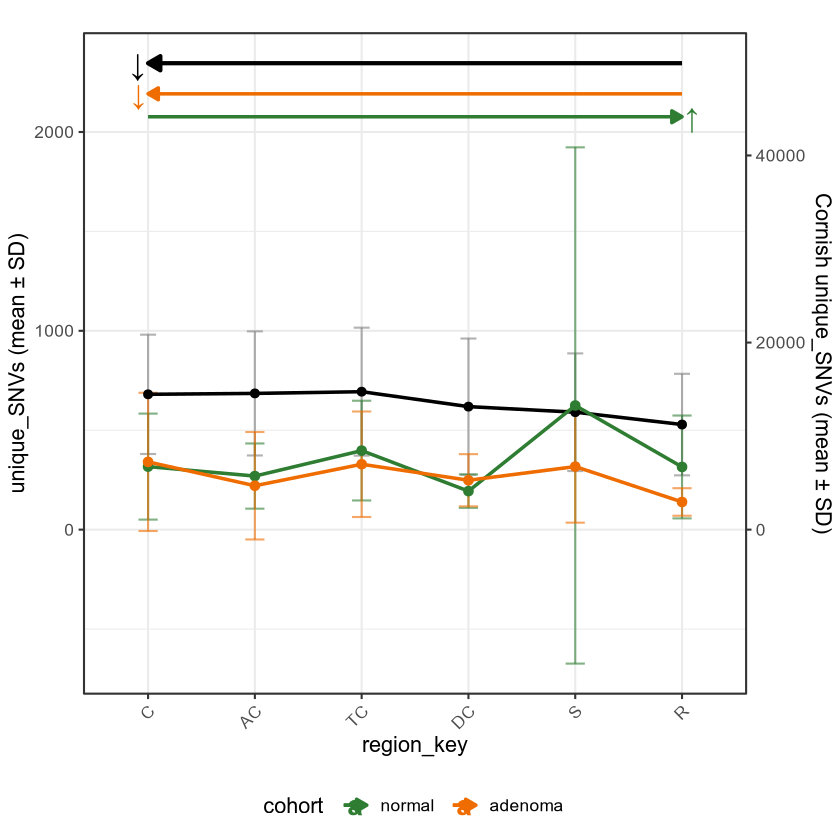

Warning message:
“Removed 3 rows containing missing values or values outside the scale range
(`geom_line()`).”
Warning message:
“Removed 3 rows containing missing values or values outside the scale range
(`geom_point()`).”


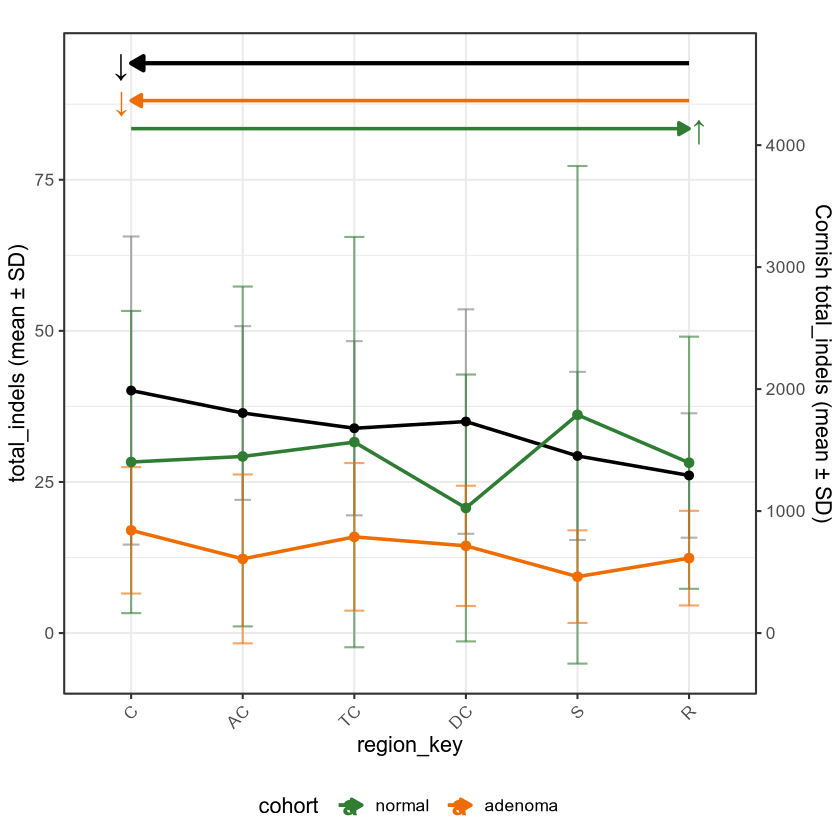

Warning message:
“Removed 3 rows containing missing values or values outside the scale range
(`geom_line()`).”
Warning message:
“Removed 3 rows containing missing values or values outside the scale range
(`geom_point()`).”


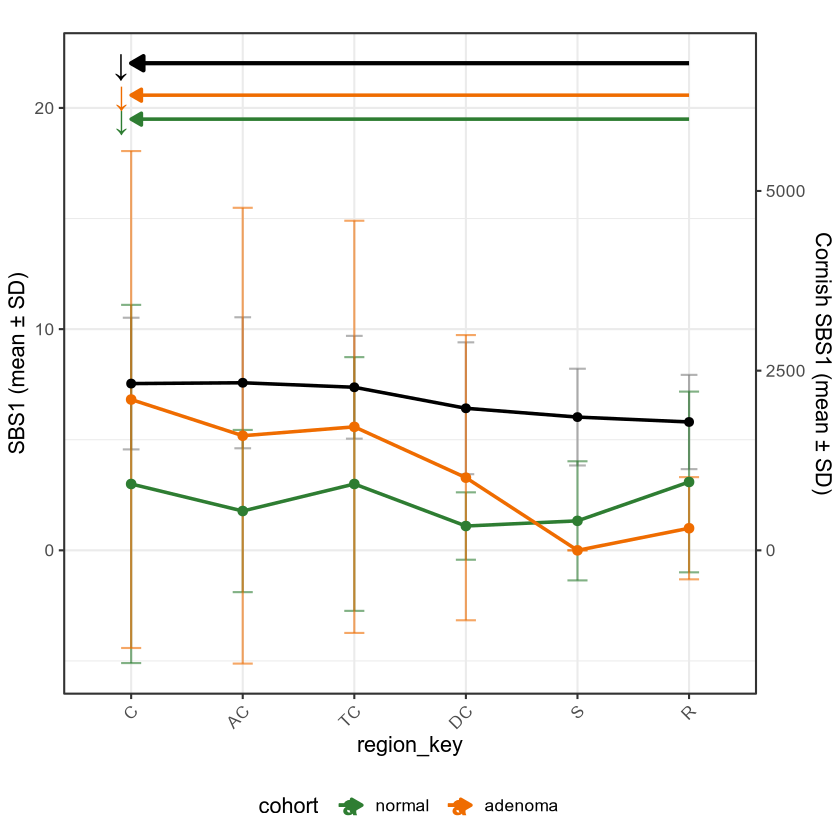

Warning message in max(summary_sig$mean, na.rm = TRUE):
“no non-missing arguments to max; returning -Inf”
Warning message in max(summary_sig$mean + summary_sig$sd, na.rm = TRUE):
“no non-missing arguments to max; returning -Inf”


ERROR: [1m[33mError[39m in `summarise()`:[22m
[1m[22m[36mℹ[39m In argument: `slope = coef(lm(mean ~ region_num))[2]`.
[1mCaused by error in `lm.fit()`:[22m
[33m![39m 0 (non-NA) cases


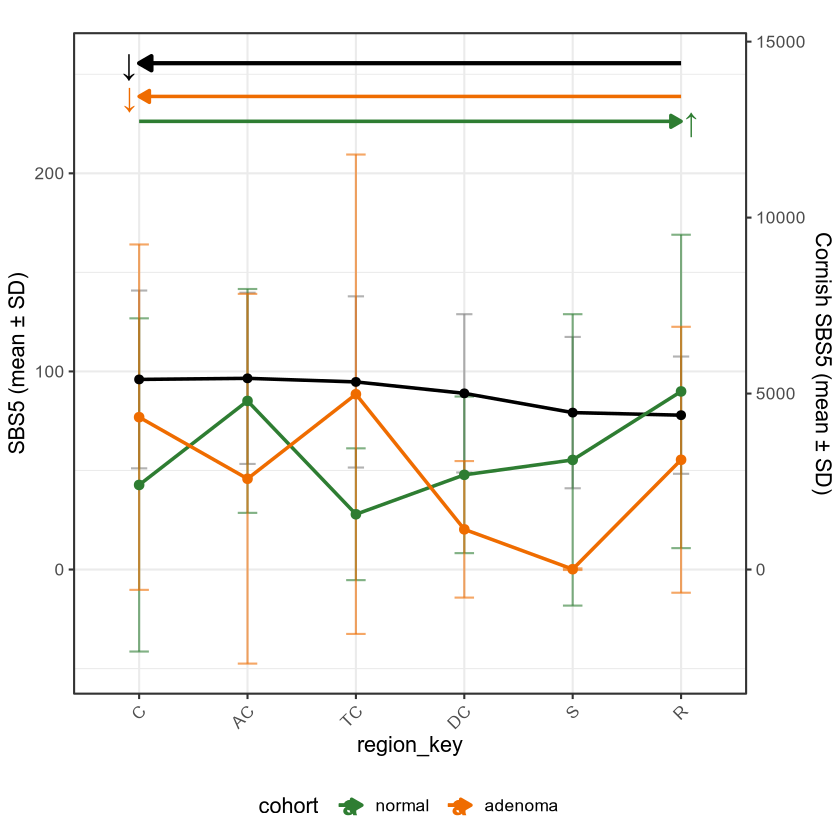

In [8]:
Cornish_site_SNV <- data.frame(
                       stringsAsFactors = FALSE,
  primary_tumour_site_more_specific_idx = c("cecum","asc_col","HF",
                                            "trans_col","SF","desc_col",
                                            "sig_col","RS","rectum"),
                             n_snv_Mean = c(14467,14563,14701,
                                            14747,12253,13149,12554,10686,11235),
                                 Median = c(13318,13544,12817,
                                            12867,10507,11826,10725,9496,10176),
                                Minimum = c(5008,6016,7739,5370,
                                            5449,4006,5018,4703,3402),
                                Maximum = c(43732,48510,46033,
                                            43643,23472,42561,47847,27835,42638),
                     Standard.Deviation = c(6378,6636,7974,6842,
                                            5061,7280,6289,4093,5427),
                    Interquartile.Range = c(6428,6362,5398,8255,
                                            6188,6751,5944,4270,5162),
                              n.tumours = c(158L,79L,21L,60L,21L,
                                            34L,262L,98L,173L)
)


Cornish_site_SNVs <- tibble::tribble(
  ~region_key, ~Cornish_Mean, ~Cornish_Median, ~Cornish_Minimum, ~Cornish_Maximum,
  "cecum",   14467, 13318, 5008,  43732,
  "asc_col", 14563, 13544, 6016,  48510,
  "HF",      14701, 12817, 7739,  46033,
  "trans_col",14747,12867, 5370,  43643,
  "SF",      12253, 10507, 5449,  23472,
  "desc_col",13149,11826, 4006,  42561,
  "sig_col", 12554,10725, 5018,  47847,
  "RS",      10686, 9496,  4703,  27835,
  "rectum",  11235,10176, 3402,  42638
)

# ---- DEFINE Cornish reference data.frames (numeric values — no commas) ----
Cornish_SNVs <- data.frame(
  region_key = c("cecum","asc_col","HF","trans_col","SF","desc_col","sig_col","RS","rectum"),
  Cornish_Mean = c(14467, 14563, 14701, 14747, 12253, 13149, 12554, 10686, 11235),
  Cornish_SD   = c(6378, 6636, 7974, 6842, 5061, 7280, 6289, 4093, 5427),
  stringsAsFactors = FALSE
)

Cornish_INDELs <- data.frame(
  region_key = c("cecum","asc_col","HF","trans_col","SF","desc_col","sig_col","RS","rectum"),
  Cornish_Mean = c(1988,1804,1615,1679,1502,1734,1452,1333,1292),
  Cornish_SD   = c(1263,712,507,714,819,920,689,593,510),
  stringsAsFactors = FALSE
)

Cornish_SBS18 <- data.frame(
  region_key = c("cecum","asc_col","HF","trans_col","SF","desc_col","sig_col","RS","rectum"),
  Cornish_Mean = c(3807.98,3375.80,3482.71,3056.58,2309.67,2628.68,2226.31,2244.63,1916.16),
  Cornish_SD   = c(2523.83,1565.50,1402.03,2211.55,1803.30,2046.63,1790.99,1445.30,1394.51),
  stringsAsFactors = FALSE
)

Cornish_SBS1 <- data.frame(
  region_key = c("cecum","asc_col","HF","trans_col","SF","desc_col","sig_col","RS","rectum"),
  Cornish_Mean = c(2320.16,2331.44,2239.48,2268.68,1955.38,1976.35,1853.96,1823.53,1785.93),
  Cornish_SD   = c(915.63,911.38,618.52,715.21,583.03,917.33,672.62,705.91,655.73),
  stringsAsFactors = FALSE
)

Cornish_SBS5 <- data.frame(
  region_key = c("cecum","asc_col","HF","trans_col","SF","desc_col","sig_col","RS","rectum"),
  Cornish_Mean = c(5401.74,5432.66,5623.10,5330.62,5381.14,5006.29,4458.89,4423.61,4385.60),
  Cornish_SD   = c(2525.62,2432.57,4465.54,2432.91,2599.82,2248.67,2150.13,1451.04,1666.24),
  stringsAsFactors = FALSE
)

Cornish_ID18 <- data.frame(
  region_key = c("cecum","asc_col","HF","trans_col","SF","desc_col","sig_col","RS","rectum"),
  Cornish_Mean = c(29.25,24.32,40.19,15.78,49.52,33.82,40.39,68.62,92.84),
  Cornish_SD   = c(142.37,111.71,175.27,64.45,125.31,94.09,129.90,124.93,170.07),
  stringsAsFactors = FALSE
)

Cornish_ID1 <- data.frame(
  region_key = c("cecum","asc_col","HF","trans_col","SF","desc_col","sig_col","RS","rectum"),
  Cornish_Mean = c(1003.53,869.67,777.38,799.08,728.33,859.00,661.12,666.17,588.47),
  Cornish_SD   = c(1028.05,365.33,248.58,357.31,422.03,432.08,316.71,313.51,273.67),
  stringsAsFactors = FALSE
)

Cornish_ID2 <- data.frame(
  region_key = c("cecum","asc_col","HF","trans_col","SF","desc_col","sig_col","RS","rectum"),
  Cornish_Mean = c(940.35,838.67,808.86,807.33,715.90,805.65,613.67,556.61,538.84),
  Cornish_SD   = c(482.24,436.48,216.09,392.54,451.04,629.53,436.80,324.21,328.95),
  stringsAsFactors = FALSE
)

region_col <- "region"
cohort_col <- "cohort"

df_raw <- Hiatt
plot_columns <- c("unique_SNVs", "total_indels", "SBS1", "SBS5", "ID2")


# ------------------------------
# cohort normalisation
# ------------------------------
normalise_cohort <- function(x) {
  x0 <- ifelse(is.na(x) | x == "", NA_character_, tolower(x) %>% str_trim())
  xc <- str_replace_all(x0, "[^a-z0-9]", "")
  dplyr::case_when(
    xc %in% c("normal","n","norm","ctrl","control","healthy","nonneoplastic") ~ "normal",
    xc %in% c("adenoma","adeno","adenomatous") ~ "adenoma",
    xc %in% c("carcinoma","crc","cancer","tumour","tumor") ~ "carcinoma",
    TRUE ~ ifelse(is.na(x0), "unknown", x0)
  )
}

# ------------------------------
# Cornish bowel order
# ------------------------------
cornish_order <- c(
  "cecum",
  "asc_col",
  "HF",
  "trans_col",
  "SF",
  "desc_col",
  "sig_col",
  "RS",
  "rectum"
)

# ------------------------------
# base dataframe
# ------------------------------
df_base <- df_raw %>%
  mutate(
    region = as.character(.data[[region_col]]) %>% str_trim(),
    cohort_raw = if (cohort_col %in% names(df_raw)) as.character(.data[[cohort_col]]) else NA_character_,
    cohort = normalise_cohort(cohort_raw)
  ) %>%
  mutate(
    region = if_else(
      region %in% c("C","AC","HC","TC","DC","S","R"),
      recode(
        region,
        "C"  = "cecum",
        "AC" = "asc_col",
        "HC" = "HF",
        "TC" = "trans_col",
        "DC" = "desc_col",
        "S"  = "sig_col",
        "R"  = "rectum"
      ),
      region
    )
  )

present_regions <- intersect(unique(df_base$region), cornish_order)
if (length(present_regions) == 0)
  stop("No overlapping regions between your data and expected region keys.")

region_levels <- cornish_order[cornish_order %in% present_regions]

df_base <- df_base %>%
  filter(region %in% region_levels) %>%
  mutate(
    region = factor(region, levels = region_levels),
    cohort = factor(cohort, levels = c("normal","adenoma","carcinoma"))
  )
df_long <- df_base %>%
  pivot_longer(
    cols = all_of(plot_columns),
    names_to = "signature",
    values_to = "value"
  )


df_long <- df_base %>%
  pivot_longer(
    cols = all_of(plot_columns),
    names_to = "signature",
    values_to = "value"
  )

plot_faceted_signature_page <- function(signature_name, cornish_df) {

  df_sig <- df_long %>%
    filter(signature == signature_name)

  summary_sig <- df_sig %>%
    group_by(region, cohort) %>%
    summarise(
      mean = mean(value, na.rm = TRUE),
      sd   = sd(value, na.rm = TRUE),
      .groups = "drop"
    )

  # ----------------------------------
  # Cornish scaling
  # ----------------------------------
  max_you     <- max(summary_sig$mean, na.rm = TRUE)
  max_cornish <- max(cornish_df$Cornish_Mean, na.rm = TRUE)

  scale_factor <- ifelse(
    is.na(max_you) | max_you <= 0,
    1,
    pmax(1, max_cornish / max_you * 0.9)
  )

  cornish_df <- cornish_df %>%
    mutate(
      Cornish_Mean_scaled = Cornish_Mean / scale_factor,
      Cornish_SD_scaled   = Cornish_SD   / scale_factor,
      region_key = factor(region_key, levels = region_levels)
    )

  # ----------------------------------
  # Arrow height: above *all* error bars
  # ----------------------------------
  max_cohort <- max(summary_sig$mean + summary_sig$sd, na.rm = TRUE)
  max_corn   <- max(
    cornish_df$Cornish_Mean_scaled + cornish_df$Cornish_SD_scaled,
    na.rm = TRUE
  )

  y_arrow_base <- max(max_cohort, max_corn)

  # ----------------------------------
  # Direction arrows: cohorts
  # ----------------------------------
  arrow_df <- summary_sig %>%
    mutate(region_num = as.numeric(region)) %>%
    group_by(cohort) %>%
    summarise(
      slope = coef(lm(mean ~ region_num))[2],
      .groups = "drop"
    ) %>%
    mutate(
      direction = ifelse(slope > 0, "up", "down"),
      x_from = ifelse(direction == "up",
                      region_levels[1],
                      region_levels[length(region_levels)]),
      x_to   = ifelse(direction == "up",
                      region_levels[length(region_levels)],
                      region_levels[1]),
      y = y_arrow_base * case_when(
        cohort == "normal"  ~ 1.08,
        cohort == "adenoma" ~ 1.14,
        TRUE                ~ 1.08
      )
    )

  # ----------------------------------
  # Cornish direction arrow
  # ----------------------------------
  cornish_arrow <- cornish_df %>%
    mutate(region_num = as.numeric(region_key)) %>%
    summarise(
      slope = coef(lm(Cornish_Mean ~ region_num))[2]
    ) %>%
    mutate(
      direction = ifelse(slope > 0, "up", "down"),
      x_from = ifelse(direction == "up",
                      region_levels[1],
                      region_levels[length(region_levels)]),
      x_to   = ifelse(direction == "up",
                      region_levels[length(region_levels)],
                      region_levels[1]),
      y = y_arrow_base * 1.22
    )

  # ----------------------------------
  # Plot
  # ----------------------------------
  p <- ggplot(summary_sig, aes(x = region, y = mean, color = cohort)) +

    ## ---- Cornish error bars (back) ----
    geom_errorbar(
      data = cornish_df,
      aes(
        x = region_key,
        ymin = Cornish_Mean_scaled - Cornish_SD_scaled,
        ymax = Cornish_Mean_scaled + Cornish_SD_scaled
      ),
      inherit.aes = FALSE,
      width = 0.15,
      linewidth = 0.6,
      alpha = 0.6,
      color = "grey50"
    ) +

    ## ---- Cohort error bars (back) ----
    geom_errorbar(
      aes(
        ymin = mean - sd,
        ymax = mean + sd,
        group = cohort
      ),
      width = 0.18,
      linewidth = 0.6,
      alpha = 0.6
    ) +

    ## ---- Cornish mean line + points ----
    geom_line(
      data = cornish_df,
      aes(x = region_key, y = Cornish_Mean_scaled, group = 1),
      inherit.aes = FALSE,
      color = "black",
      linewidth = 1
    ) +
    geom_point(
      data = cornish_df,
      aes(x = region_key, y = Cornish_Mean_scaled),
      inherit.aes = FALSE,
      color = "black",
      size = 2
    ) +

    ## ---- Cohort trend lines + points ----
    geom_line(aes(group = cohort), linewidth = 1) +
    geom_point(size = 2.2) +

    ## ---- Cohort arrows ----
    geom_segment(
      data = arrow_df,
      aes(x = x_from, xend = x_to, y = y, yend = y, color = cohort),
      arrow = arrow(length = unit(0.25, "cm"), type = "closed"),
      linewidth = 1,
      inherit.aes = FALSE
    ) +
    geom_text(
      data = arrow_df,
      aes(
        x = x_to,
        y = y,
        label = ifelse(direction == "up", "↑", "↓"),
        color = cohort
      ),
      hjust = ifelse(arrow_df$direction == "up", -0.2, 1.2),
      size = 6,
      fontface = "bold",
      inherit.aes = FALSE
    ) +

    ## ---- Cornish arrow (top) ----
    geom_segment(
      data = cornish_arrow,
      aes(x = x_from, xend = x_to, y = y, yend = y),
      arrow = arrow(length = unit(0.3, "cm"), type = "closed"),
      linewidth = 1.2,
      color = "black",
      inherit.aes = FALSE
    ) +
    geom_text(
      data = cornish_arrow,
      aes(
        x = x_to,
        y = y,
        label = ifelse(direction == "up", "↑", "↓")
      ),
      hjust = ifelse(cornish_arrow$direction == "up", -0.2, 1.2),
      size = 6.5,
      fontface = "bold",
      color = "black",
      inherit.aes = FALSE
    ) +

    scale_color_manual(
      values = c(
        normal  = "#2E7D32",  # green
        adenoma = "#EF6C00"   # orange
      )
    ) +

    scale_x_discrete(
      limits = region_levels,
      labels = c(
        "cecum"="C","asc_col"="AC","HF"="HC",
        "trans_col"="TC","SF"="SF","desc_col"="DC",
        "sig_col"="S","RS"="RS","rectum"="R"
      )
    ) +

    scale_y_continuous(
      name = paste0(signature_name, " (mean ± SD)"),
      sec.axis = sec_axis(
        ~ . * scale_factor,
        name = paste0("Cornish ", signature_name, " (mean ± SD)")
      )
    ) +

    coord_cartesian(clip = "off") +
    theme_bw(base_size = 13) +
    theme(
      axis.text.x = element_text(angle = 45, hjust = 1),
      legend.position = "bottom",
      plot.margin = margin(t = 20, r = 5, b = 5, l = 5)
    )

  print(p)
}

plot_faceted_signature_page("unique_SNVs",  Cornish_SNVs)
plot_faceted_signature_page("total_indels", Cornish_INDELs)
plot_faceted_signature_page("SBS1",  Cornish_SBS1)
plot_faceted_signature_page("SBS5",  Cornish_SBS5)
plot_faceted_signature_page("ID1",  Cornish_ID1)
plot_faceted_signature_page("ID2",  Cornish_ID2)


NULL

Warning message:
“Removed 3 rows containing missing values or values outside the scale range
(`geom_line()`).”
Warning message:
“Removed 3 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 3 rows containing missing values or values outside the scale range
(`geom_line()`).”
Warning message:
“Removed 3 rows containing missing values or values outside the scale range
(`geom_point()`).”


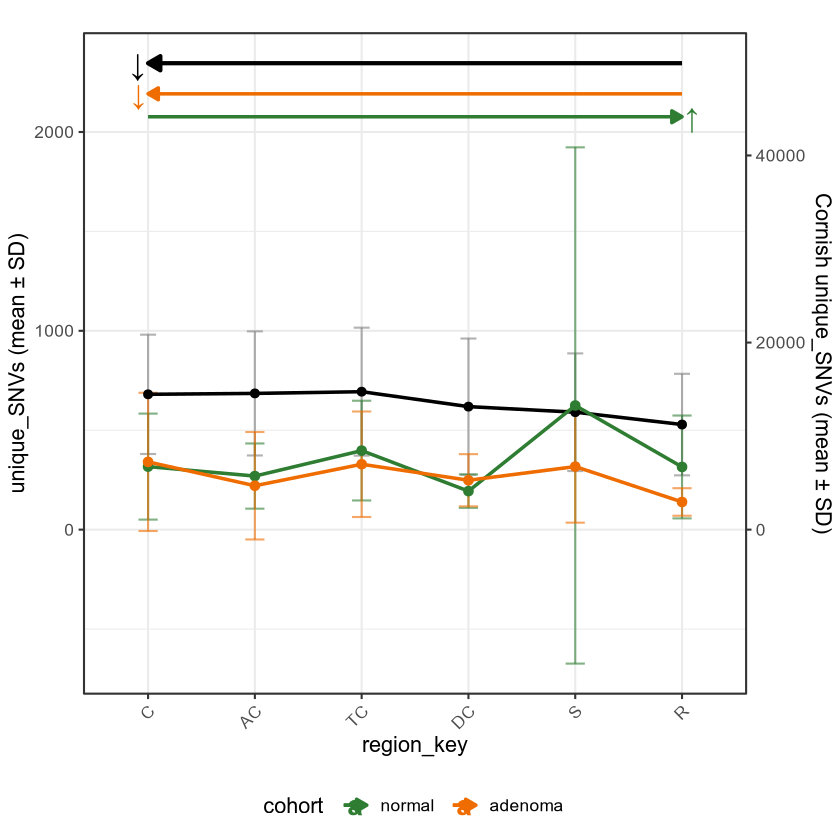

Warning message:
“Removed 3 rows containing missing values or values outside the scale range
(`geom_line()`).”
Warning message:
“Removed 3 rows containing missing values or values outside the scale range
(`geom_point()`).”


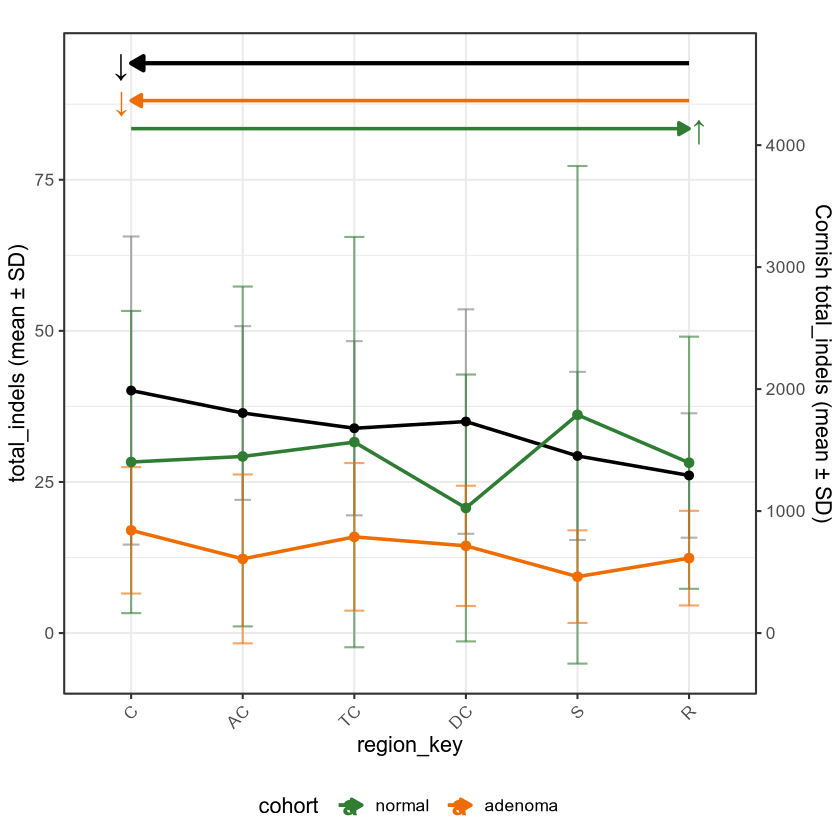

Warning message:
“Removed 3 rows containing missing values or values outside the scale range
(`geom_line()`).”
Warning message:
“Removed 3 rows containing missing values or values outside the scale range
(`geom_point()`).”


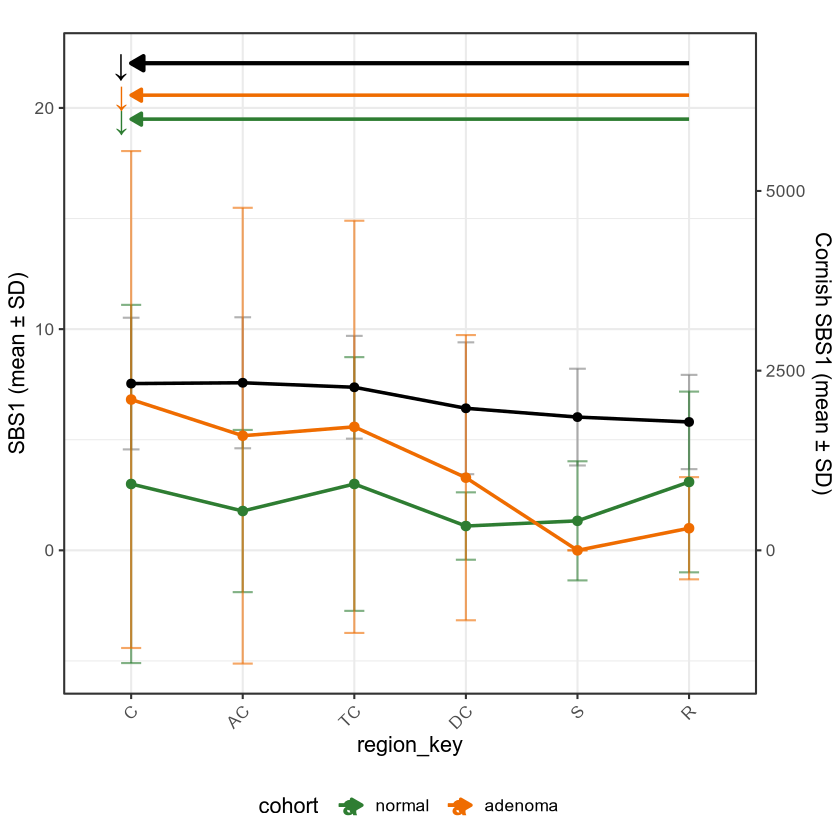

Warning message:
“Removed 3 rows containing missing values or values outside the scale range
(`geom_line()`).”
Warning message:
“Removed 3 rows containing missing values or values outside the scale range
(`geom_point()`).”


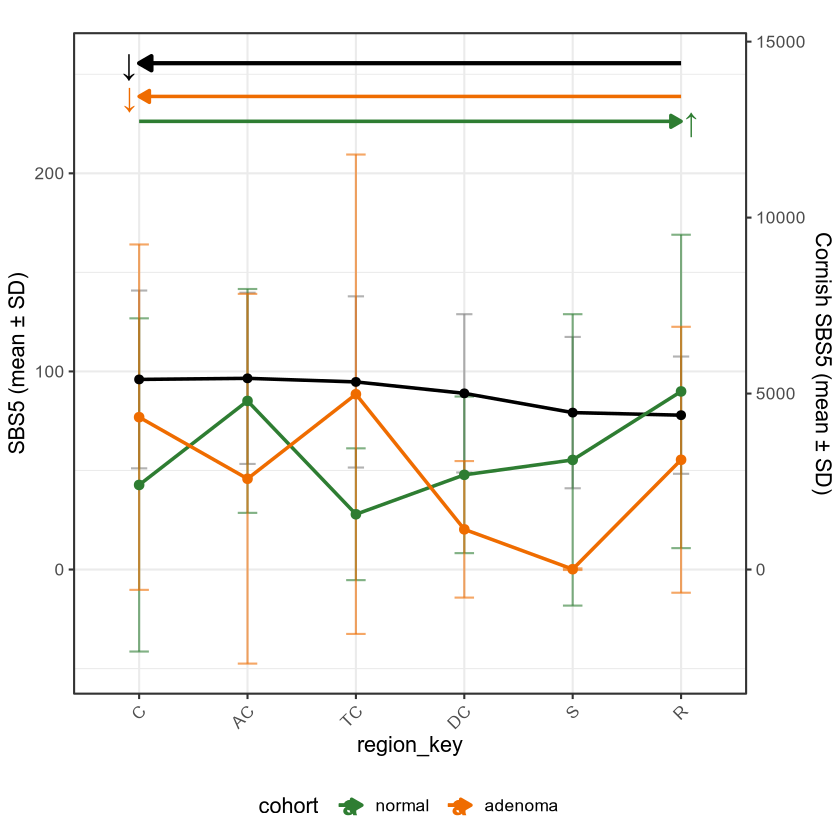

Warning message in max(summary_sig$mean, na.rm = TRUE):
“no non-missing arguments to max; returning -Inf”
Warning message in max(summary_sig$mean + summary_sig$sd, na.rm = TRUE):
“no non-missing arguments to max; returning -Inf”


ERROR: [1m[33mError[39m in `summarise()`:[22m
[1m[22m[36mℹ[39m In argument: `slope = coef(lm(mean ~ region_num))[2]`.
[1mCaused by error in `lm.fit()`:[22m
[33m![39m 0 (non-NA) cases


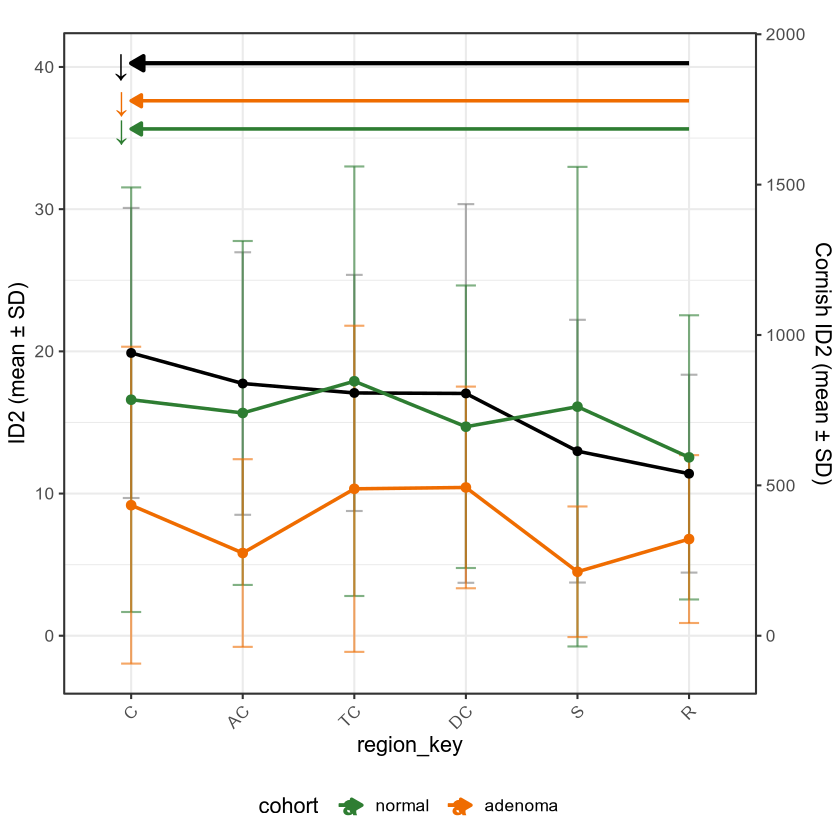

In [10]:
cornish_SNVs_subclonal <- plot_faceted_signature_page("unique_SNVs",  Cornish_SNVs)
cornish_INDELs_subclonal <- plot_faceted_signature_page("total_indels", Cornish_INDELs)
cornish_SBS1_subclonal <- plot_faceted_signature_page("SBS1",  Cornish_SBS1)
cornish_SBS5_subclonal <- plot_faceted_signature_page("SBS5",  Cornish_SBS5)
cornish_ID2_subclonal <- plot_faceted_signature_page("ID2",  Cornish_ID2)
cornish_ID1_subclonal <- plot_faceted_signature_page("ID1",  Cornish_ID1)


ggsave(filename = "Figure3/cornish_SNVs_subclonal.svg", plot = cornish_SNVs_subclonal, width = 10, height = 8, units = "in")
ggsave(filename = "Figure4/cornish_INDELs_subclonal.svg", plot = cornish_INDELs_subclonal, width = 10, height = 8,  units = "in")
ggsave(filename = "Figure3/cornish_SBS1_subclonal.svg", plot = cornish_SBS1_subclonal, width = 10, height = 8, units = "in")
ggsave(filename = "Figure3/cornish_SBS5_subclonal.svg", plot = cornish_SBS5_subclonal, width = 10, height  = 8, units = "in")
ggsave(filename = "Figure4/cornish_ID2_subclonal.svg", plot =   cornish_ID2_subclonal, width = 10, height = 8, units = "in")
ggsave(filename = "Figure4/cornish_ID1_subclonal.svg", plot =   cornish_ID1_subclonal, width = 10, height = 8, units = "in")

### Clonal

In [ ]:
Cornish_site_SNV <- data.frame(
                       stringsAsFactors = FALSE,
  primary_tumour_site_more_specific_idx = c("cecum","asc_col","HF",
                                            "trans_col","SF","desc_col",
                                            "sig_col","RS","rectum"),
                             n_snv_Mean = c(14467,14563,14701,
                                            14747,12253,13149,12554,10686,11235),
                                 Median = c(13318,13544,12817,
                                            12867,10507,11826,10725,9496,10176),
                                Minimum = c(5008,6016,7739,5370,
                                            5449,4006,5018,4703,3402),
                                Maximum = c(43732,48510,46033,
                                            43643,23472,42561,47847,27835,42638),
                     Standard.Deviation = c(6378,6636,7974,6842,
                                            5061,7280,6289,4093,5427),
                    Interquartile.Range = c(6428,6362,5398,8255,
                                            6188,6751,5944,4270,5162),
                              n.tumours = c(158L,79L,21L,60L,21L,
                                            34L,262L,98L,173L)
)


Cornish_site_SNVs <- tibble::tribble(
  ~region_key, ~Cornish_Mean, ~Cornish_Median, ~Cornish_Minimum, ~Cornish_Maximum,
  "cecum",   14467, 13318, 5008,  43732,
  "asc_col", 14563, 13544, 6016,  48510,
  "HF",      14701, 12817, 7739,  46033,
  "trans_col",14747,12867, 5370,  43643,
  "SF",      12253, 10507, 5449,  23472,
  "desc_col",13149,11826, 4006,  42561,
  "sig_col", 12554,10725, 5018,  47847,
  "RS",      10686, 9496,  4703,  27835,
  "rectum",  11235,10176, 3402,  42638
)

# ---- DEFINE Cornish reference data.frames (numeric values — no commas) ----
Cornish_SNVs <- data.frame(
  region_key = c("cecum","asc_col","HF","trans_col","SF","desc_col","sig_col","RS","rectum"),
  Cornish_Mean = c(14467, 14563, 14701, 14747, 12253, 13149, 12554, 10686, 11235),
  Cornish_SD   = c(6378, 6636, 7974, 6842, 5061, 7280, 6289, 4093, 5427),
  stringsAsFactors = FALSE
)

Cornish_INDELs <- data.frame(
  region_key = c("cecum","asc_col","HF","trans_col","SF","desc_col","sig_col","RS","rectum"),
  Cornish_Mean = c(1988,1804,1615,1679,1502,1734,1452,1333,1292),
  Cornish_SD   = c(1263,712,507,714,819,920,689,593,510),
  stringsAsFactors = FALSE
)

Cornish_SBS18 <- data.frame(
  region_key = c("cecum","asc_col","HF","trans_col","SF","desc_col","sig_col","RS","rectum"),
  Cornish_Mean = c(3807.98,3375.80,3482.71,3056.58,2309.67,2628.68,2226.31,2244.63,1916.16),
  Cornish_SD   = c(2523.83,1565.50,1402.03,2211.55,1803.30,2046.63,1790.99,1445.30,1394.51),
  stringsAsFactors = FALSE
)

Cornish_SBS1 <- data.frame(
  region_key = c("cecum","asc_col","HF","trans_col","SF","desc_col","sig_col","RS","rectum"),
  Cornish_Mean = c(2320.16,2331.44,2239.48,2268.68,1955.38,1976.35,1853.96,1823.53,1785.93),
  Cornish_SD   = c(915.63,911.38,618.52,715.21,583.03,917.33,672.62,705.91,655.73),
  stringsAsFactors = FALSE
)

Cornish_SBS5 <- data.frame(
  region_key = c("cecum","asc_col","HF","trans_col","SF","desc_col","sig_col","RS","rectum"),
  Cornish_Mean = c(5401.74,5432.66,5623.10,5330.62,5381.14,5006.29,4458.89,4423.61,4385.60),
  Cornish_SD   = c(2525.62,2432.57,4465.54,2432.91,2599.82,2248.67,2150.13,1451.04,1666.24),
  stringsAsFactors = FALSE
)

Cornish_ID18 <- data.frame(
  region_key = c("cecum","asc_col","HF","trans_col","SF","desc_col","sig_col","RS","rectum"),
  Cornish_Mean = c(29.25,24.32,40.19,15.78,49.52,33.82,40.39,68.62,92.84),
  Cornish_SD   = c(142.37,111.71,175.27,64.45,125.31,94.09,129.90,124.93,170.07),
  stringsAsFactors = FALSE
)

Cornish_ID1 <- data.frame(
  region_key = c("cecum","asc_col","HF","trans_col","SF","desc_col","sig_col","RS","rectum"),
  Cornish_Mean = c(1003.53,869.67,777.38,799.08,728.33,859.00,661.12,666.17,588.47),
  Cornish_SD   = c(1028.05,365.33,248.58,357.31,422.03,432.08,316.71,313.51,273.67),
  stringsAsFactors = FALSE
)

Cornish_ID2 <- data.frame(
  region_key = c("cecum","asc_col","HF","trans_col","SF","desc_col","sig_col","RS","rectum"),
  Cornish_Mean = c(940.35,838.67,808.86,807.33,715.90,805.65,613.67,556.61,538.84),
  Cornish_SD   = c(482.24,436.48,216.09,392.54,451.04,629.53,436.80,324.21,328.95),
  stringsAsFactors = FALSE
)

plot_columns <- c("unique_SNVs", "total_indels", "SBS18", "SBS1", "SBS5", "ID18", "ID1", "ID2")


# study dataframes
Hiatt = read.csv('/uufs/chpc.utah.edu/common/HIPAA/u1264408/u1264408/Git/SEMIColon/data/output/CellCut/Hiattdataframe.csv',
                 stringsAsFactors = FALSE, header = TRUE)

Hiatt$sex <- "male"


pattern_right <- "cecum|asc_col|trans_col"
pattern_left  <- "desc_col|sig_col|rectum"

Hiatt <- Hiatt %>%
  mutate(side = case_when(
    str_detect(region, regex(pattern_right, ignore_case = TRUE)) ~ "Right",
    str_detect(region, regex(pattern_left,  ignore_case = TRUE)) ~ "Left",
    TRUE ~ region
  ))

# Add origin column to each dataframe
Hiatt$study <- "Hiatt"

# additional data
denom = read.csv('/uufs/chpc.utah.edu/common/HIPAA/u1264408/u1264408/Git/SEMIColon/data/output/CellCut/mosdepth/per_base/depth8_totals.csv', stringsAsFactors = FALSE, header = FALSE)
colnames(denom)[1] <- "crypt_sample"
colnames(denom)[2] <- "depth"
Hiatt <- merge(denom, Hiatt, by = "crypt_sample")
Hiatt$depth <- as.numeric(Hiatt$depth)

# Make sure factor variables are ordered properly
Hiatt$cohort <- factor(Hiatt$cohort)
Hiatt$donor <- factor(Hiatt$donor)
Hiatt$side <- factor(Hiatt$side)
Hiatt$sex <- factor(Hiatt$sex)

SBSActivities <-  read.csv('/uufs/chpc.utah.edu/common/HIPAA/u1264408/u1264408/Git/SEMIColon/scripts/mutations/signatures/snvs/snvs_other/SBS288/Suggested_Solution/COSMIC_SBS288_Decomposed_Solution/Activities/COSMIC_SBS288_Activities.txt', stringsAsFactors = FALSE, header = TRUE, sep = "\t")
IDActivities <-  read.csv('/uufs/chpc.utah.edu/common/HIPAA/u1264408/u1264408/Git/SEMIColon/scripts/mutations/signatures/ID/ID_other/ID83/Suggested_Solution/COSMIC_ID83_Decomposed_Solution/Activities/COSMIC_ID83_Activities.txt', stringsAsFactors = FALSE, header = TRUE, sep = "\t")

merge_function <- function(x, y) {
  merge(x, y, by = "Samples", all = TRUE) # Adjust 'all' argument for desired join type
}

activities_list <- list(SBSActivities, IDActivities)
Activities <- Reduce(merge_function, activities_list)
Activities <- Activities %>%
  rename("crypt_sample" = "Samples")

Activities[is.na(Activities)] <- 0
Hiatt <- merge(Hiatt, Activities, by = "crypt_sample", all = FALSE)
Hiatt <- subset(Hiatt, coverage > 9)
Hiatt <- subset(Hiatt, unique_SNVs > 500)

# Add a new column that sums all columns starting with "SBS"
Hiatt$SBS_total <- rowSums(Hiatt[, grepl("^SBS", colnames(Hiatt))], na.rm = TRUE)
# Replace the unique_SNVs column with that total
Hiatt$unique_SNVs <- Hiatt$SBS_total
# (Optional) remove the temporary total column if you don't want to keep it
Hiatt$SBS_total <- NULL

Hiatt$total_indels <- rowSums(Hiatt[, grepl("^ID", colnames(Hiatt))], na.rm = TRUE)


In [ ]:
all_cols <- names(Hiatt)
sig_prefixes <- c("^SBS", "^ID")  # prefixes for signature columns
sig_cols <- all_cols[Reduce(`|`, lapply(sig_prefixes, function(p) grepl(p, all_cols)))]
sig_cols <- sig_cols[!grepl("_", sig_cols)]

region_order <- c("Right", "cecum", "asc_col", "trans_col",
                  "desc_col", "sig_col", "rectum", "Left")

In [ ]:
region_col <- "region"
cohort_col <- "cohort"

df_raw <- Hiatt

# ------------------------------
# cohort normalisation
# ------------------------------
normalise_cohort <- function(x) {
  x0 <- ifelse(is.na(x) | x == "", NA_character_, tolower(x) %>% str_trim())
  xc <- str_replace_all(x0, "[^a-z0-9]", "")
  dplyr::case_when(
    xc %in% c("normal","n","norm","ctrl","control","healthy","nonneoplastic") ~ "normal",
    xc %in% c("adenoma","adeno","adenomatous") ~ "adenoma",
    xc %in% c("carcinoma","crc","cancer","tumour","tumor") ~ "carcinoma",
    TRUE ~ ifelse(is.na(x0), "unknown", x0)
  )
}

# ------------------------------
# Cornish bowel order
# ------------------------------
cornish_order <- c(
  "cecum",
  "asc_col",
  "HF",
  "trans_col",
  "SF",
  "desc_col",
  "sig_col",
  "RS",
  "rectum"
)

# ------------------------------
# base dataframe
# ------------------------------
df_base <- df_raw %>%
  mutate(
    region = as.character(.data[[region_col]]) %>% str_trim(),
    cohort_raw = if (cohort_col %in% names(df_raw)) as.character(.data[[cohort_col]]) else NA_character_,
    cohort = normalise_cohort(cohort_raw)
  ) %>%
  mutate(
    region = if_else(
      region %in% c("C","AC","HC","TC","DC","S","R"),
      recode(
        region,
        "C"  = "cecum",
        "AC" = "asc_col",
        "HC" = "HF",
        "TC" = "trans_col",
        "DC" = "desc_col",
        "S"  = "sig_col",
        "R"  = "rectum"
      ),
      region
    )
  )

present_regions <- intersect(unique(df_base$region), cornish_order)
if (length(present_regions) == 0)
  stop("No overlapping regions between your data and expected region keys.")

region_levels <- cornish_order[cornish_order %in% present_regions]

df_base <- df_base %>%
  filter(region %in% region_levels) %>%
  mutate(
    region = factor(region, levels = region_levels),
    cohort = factor(cohort, levels = c("normal","adenoma","carcinoma"))
  )
df_long <- df_base %>%
  pivot_longer(
    cols = all_of(plot_columns),
    names_to = "signature",
    values_to = "value"
  )

plot_faceted_signature_page <- function(signature_name, cornish_df) {

  df_sig <- df_long %>%
    filter(signature == signature_name)

  summary_sig <- df_sig %>%
    group_by(region, cohort) %>%
    summarise(
      mean = mean(value, na.rm = TRUE),
      sd   = sd(value, na.rm = TRUE),
      .groups = "drop"
    )

  # ----------------------------------
  # Cornish scaling
  # ----------------------------------
  max_you     <- max(summary_sig$mean, na.rm = TRUE)
  max_cornish <- max(cornish_df$Cornish_Mean, na.rm = TRUE)

  scale_factor <- ifelse(
    is.na(max_you) | max_you <= 0,
    1,
    pmax(1, max_cornish / max_you * 0.9)
  )

  cornish_df <- cornish_df %>%
    mutate(
      Cornish_Mean_scaled = Cornish_Mean / scale_factor,
      Cornish_SD_scaled   = Cornish_SD   / scale_factor,
      region_key = factor(region_key, levels = region_levels)
    )

  # ----------------------------------
  # Arrow height: above *all* error bars
  # ----------------------------------
  max_cohort <- max(summary_sig$mean + summary_sig$sd, na.rm = TRUE)
  max_corn   <- max(
    cornish_df$Cornish_Mean_scaled + cornish_df$Cornish_SD_scaled,
    na.rm = TRUE
  )

  y_arrow_base <- max(max_cohort, max_corn)

  # ----------------------------------
  # Direction arrows: cohorts
  # ----------------------------------
  arrow_df <- summary_sig %>%
    mutate(region_num = as.numeric(region)) %>%
    group_by(cohort) %>%
    summarise(
      slope = coef(lm(mean ~ region_num))[2],
      .groups = "drop"
    ) %>%
    mutate(
      direction = ifelse(slope > 0, "up", "down"),
      x_from = ifelse(direction == "up",
                      region_levels[1],
                      region_levels[length(region_levels)]),
      x_to   = ifelse(direction == "up",
                      region_levels[length(region_levels)],
                      region_levels[1]),
      y = y_arrow_base * case_when(
        cohort == "normal"  ~ 1.08,
        cohort == "adenoma" ~ 1.14,
        TRUE                ~ 1.08
      )
    )

  # ----------------------------------
  # Cornish direction arrow
  # ----------------------------------
  cornish_arrow <- cornish_df %>%
    mutate(region_num = as.numeric(region_key)) %>%
    summarise(
      slope = coef(lm(Cornish_Mean ~ region_num))[2]
    ) %>%
    mutate(
      direction = ifelse(slope > 0, "up", "down"),
      x_from = ifelse(direction == "up",
                      region_levels[1],
                      region_levels[length(region_levels)]),
      x_to   = ifelse(direction == "up",
                      region_levels[length(region_levels)],
                      region_levels[1]),
      y = y_arrow_base * 1.22
    )

  # ----------------------------------
  # Plot
  # ----------------------------------
  p <- ggplot(summary_sig, aes(x = region, y = mean, color = cohort)) +

    ## ---- Cornish error bars (back) ----
    geom_errorbar(
      data = cornish_df,
      aes(
        x = region_key,
        ymin = Cornish_Mean_scaled - Cornish_SD_scaled,
        ymax = Cornish_Mean_scaled + Cornish_SD_scaled
      ),
      inherit.aes = FALSE,
      width = 0.15,
      linewidth = 0.6,
      alpha = 0.6,
      color = "grey50"
    ) +

    ## ---- Cohort error bars (back) ----
    geom_errorbar(
      aes(
        ymin = mean - sd,
        ymax = mean + sd,
        group = cohort
      ),
      width = 0.18,
      linewidth = 0.6,
      alpha = 0.6
    ) +

    ## ---- Cornish mean line + points ----
    geom_line(
      data = cornish_df,
      aes(x = region_key, y = Cornish_Mean_scaled, group = 1),
      inherit.aes = FALSE,
      color = "black",
      linewidth = 1
    ) +
    geom_point(
      data = cornish_df,
      aes(x = region_key, y = Cornish_Mean_scaled),
      inherit.aes = FALSE,
      color = "black",
      size = 2
    ) +

    ## ---- Cohort trend lines + points ----
    geom_line(aes(group = cohort), linewidth = 1) +
    geom_point(size = 2.2) +

    ## ---- Cohort arrows ----
    geom_segment(
      data = arrow_df,
      aes(x = x_from, xend = x_to, y = y, yend = y, color = cohort),
      arrow = arrow(length = unit(0.25, "cm"), type = "closed"),
      linewidth = 1,
      inherit.aes = FALSE
    ) +
    geom_text(
      data = arrow_df,
      aes(
        x = x_to,
        y = y,
        label = ifelse(direction == "up", "↑", "↓"),
        color = cohort
      ),
      hjust = ifelse(arrow_df$direction == "up", -0.2, 1.2),
      size = 6,
      fontface = "bold",
      inherit.aes = FALSE
    ) +

    ## ---- Cornish arrow (top) ----
    geom_segment(
      data = cornish_arrow,
      aes(x = x_from, xend = x_to, y = y, yend = y),
      arrow = arrow(length = unit(0.3, "cm"), type = "closed"),
      linewidth = 1.2,
      color = "black",
      inherit.aes = FALSE
    ) +
    geom_text(
      data = cornish_arrow,
      aes(
        x = x_to,
        y = y,
        label = ifelse(direction == "up", "↑", "↓")
      ),
      hjust = ifelse(cornish_arrow$direction == "up", -0.2, 1.2),
      size = 6.5,
      fontface = "bold",
      color = "black",
      inherit.aes = FALSE
    ) +

    scale_color_manual(
      values = c(
        normal  = "#2E7D32",  # green
        adenoma = "#EF6C00"   # orange
      )
    ) +

    scale_x_discrete(
      limits = region_levels,
      labels = c(
        "cecum"="C","asc_col"="AC","HF"="HC",
        "trans_col"="TC","SF"="SF","desc_col"="DC",
        "sig_col"="S","RS"="RS","rectum"="R"
      )
    ) +

    scale_y_continuous(
      name = paste0(signature_name, " (mean ± SD)"),
      sec.axis = sec_axis(
        ~ . * scale_factor,
        name = paste0("Cornish ", signature_name, " (mean ± SD)")
      )
    ) +

    coord_cartesian(clip = "off") +
    theme_bw(base_size = 13) +
    theme(
      axis.text.x = element_text(angle = 45, hjust = 1),
      legend.position = "bottom",
      plot.margin = margin(t = 20, r = 5, b = 5, l = 5)
    )

  print(p)
}

plot_faceted_signature_page("unique_SNVs",  Cornish_SNVs)
plot_faceted_signature_page("total_indels", Cornish_INDELs)
plot_faceted_signature_page("SBS1",  Cornish_SBS1)
plot_faceted_signature_page("SBS5",  Cornish_SBS5)
plot_faceted_signature_page("SBS18",  Cornish_SBS18)
plot_faceted_signature_page("ID1",  Cornish_ID1)
plot_faceted_signature_page("ID2",  Cornish_ID2)
plot_faceted_signature_page("ID18",  Cornish_ID18)


In [ ]:
unique_SNVs_clonal <- plot_faceted_signature_page("unique_SNVs",  Cornish_SNVs)
total_indels_clonal <- plot_faceted_signature_page("total_indels", Cornish_INDELs)
SBS1_clonal <- plot_faceted_signature_page("SBS1",  Cornish_SBS1)
SBS5_clonal <- plot_faceted_signature_page("SBS5",  Cornish_SBS5)
SBS18_clonal <- plot_faceted_signature_page("SBS18",  Cornish_SBS18)
ID1_clonal <- plot_faceted_signature_page("ID1",  Cornish_ID1)
ID2_clonal <- plot_faceted_signature_page("ID2",  Cornish_ID2)
ID18_clonal <- plot_faceted_signature_page("ID18",  Cornish_ID18)

ggsave(filename = "Figure3/unique_SNVs_clonal.svg", plot = unique_SNVs_clonal, width = 10, height = 8, units = "in")
ggsave(filename = "Figure4/total_indels_clonal.svg", plot = total_indels_clonal, width = 10, height = 8,  units = "in")
ggsave(filename = "Figure3/SBS1_clonal.svg", plot = SBS1_clonal, width = 10, height = 8, units = "in")
ggsave(filename = "Figure3/SBS5_clonal.svg", plot = SBS5_clonal, width = 10, height  = 8, units = "in")
ggsave(filename = "Figure3/SBS18_clonal.svg", plot = SBS18_clonal, width = 10, height  = 8, units = "in")
ggsave(filename = "Figure4/ID1_clonal.svg", plot = ID1_clonal, width = 10, height = 8,  units = "in")
ggsave(filename = "Figure4/ID2_clonal.svg", plot = ID2_clonal, width = 10, height = 8,  units = "in")
ggsave(filename = "Figure4/ID18_clonal.svg", plot = ID18_clonal, width = 10, height = 8,  units = "in")